In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter

In [14]:
# 参数
CSV_PATH = 'event74_hits.csv'
EVENT = 74
LAYER = 25

In [15]:
# choose layer
df = pd.read_csv("/Users/amandadongsmacbookpro/Desktop/Gunther Research/Research/event74_hits.csv")
layer_df = df[(df['event'] == EVENT) & (df['layer'] == LAYER)]

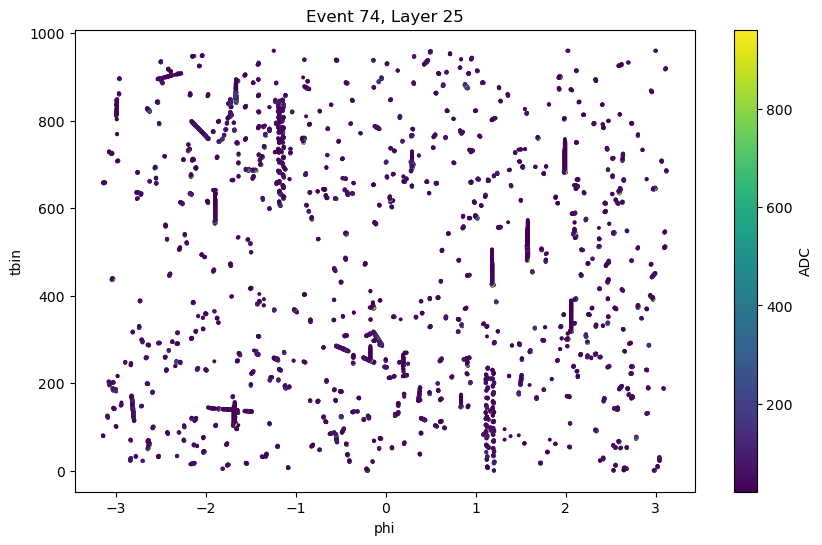

In [16]:
# build 2D network
phi_unique = np.sort(layer_df['phi'].unique())
phi_to_idx = {p: i for i, p in enumerate(phi_unique)}
tbin_min = int(layer_df['tbin'].min())
n_phi = len(phi_unique)
n_tbin = int(layer_df['tbin'].max()) - tbin_min + 1

grid = np.zeros((n_phi, n_tbin))
for _, row in layer_df.iterrows():
    grid[phi_to_idx[row['phi']], int(row['tbin']) - tbin_min] = row['adc']

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    layer_df['phi'],
    layer_df['tbin'],
    c=layer_df['adc'],
    cmap='viridis',
    s=8,
    linewidths=0,
)
fig.colorbar(scatter, ax=ax, label='ADC')
ax.set_xlabel('phi')
ax.set_ylabel('tbin')
ax.set_title(f'Event {EVENT}, Layer {LAYER}')
plt.show()

2730 local maxima found


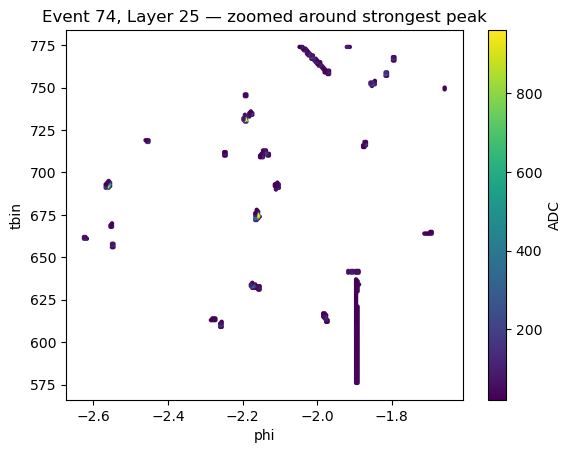

In [17]:
# zoom in and find local maximum
local_max = (maximum_filter(grid, size=3, mode='constant', cval=0) == grid) & (grid > 0)
peaks = np.argwhere(local_max)
print(f'{len(peaks)} local maxima found')

strongest = peaks[np.argmax(grid[peaks[:, 0], peaks[:, 1]])]
phi_center = float(phi_unique[strongest[0]])
tbin_center = int(strongest[1]) + tbin_min

zoom_hits = layer_df[
    (layer_df['phi'] > phi_center - 0.5) & (layer_df['phi'] < phi_center + 0.5) &
    (layer_df['tbin'] > tbin_center - 100) & (layer_df['tbin'] < tbin_center + 100)
]

fig, ax = plt.subplots()
scatter = ax.scatter(
    zoom_hits['phi'],
    zoom_hits['tbin'],
    c=zoom_hits['adc'],
    cmap='viridis',
    s=10,
    linewidths=0,
)
fig.colorbar(scatter, ax=ax, label='ADC')
ax.set_xlabel('phi')
ax.set_ylabel('tbin')
ax.set_title(f'Event {EVENT}, Layer {LAYER} — zoomed around strongest peak')
plt.show()

In [18]:
# 5x5 and 7x7 patch
results = {}
for PATCH in [5, 7]:
    half = PATCH // 2
    rows = []
    for pi, ti in peaks:
        patch = [
            grid[pi + dpi, ti + dti]
            if (0 <= pi + dpi < n_phi and 0 <= ti + dti < n_tbin) else 0.0
            for dpi in range(-half, half + 1)
            for dti in range(-half, half + 1)
        ]
        rows.append([EVENT, LAYER, float(phi_unique[pi]), int(ti + tbin_min)] + patch)
    cols = ['event', 'layer', 'phi', 'tbin'] + [f'p{k:02d}' for k in range(PATCH * PATCH)]
    results[PATCH] = pd.DataFrame(rows, columns=cols)

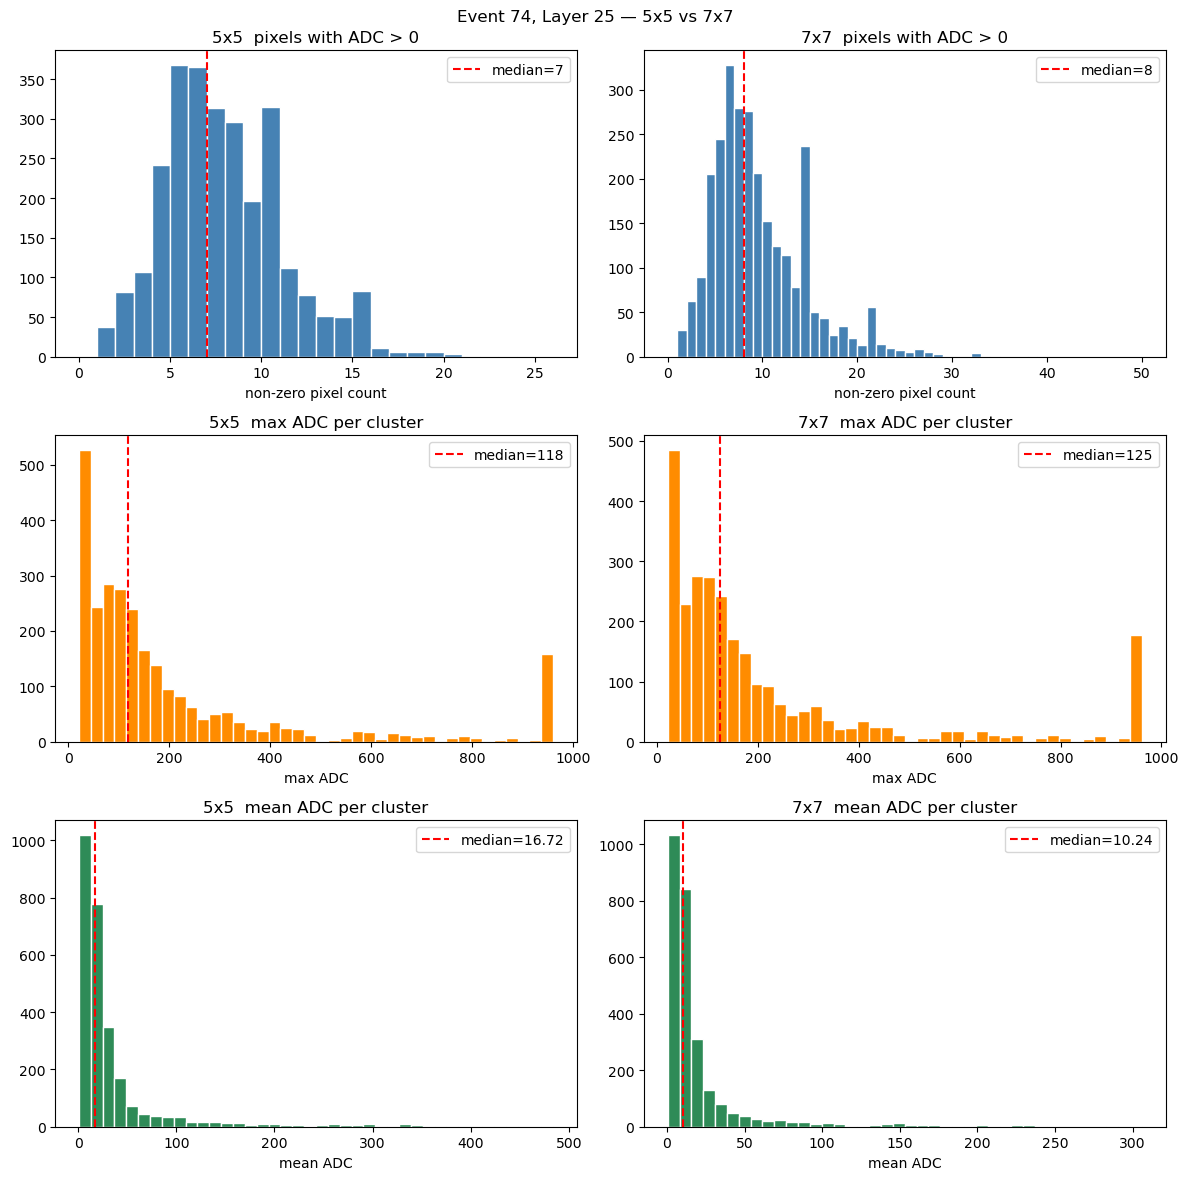

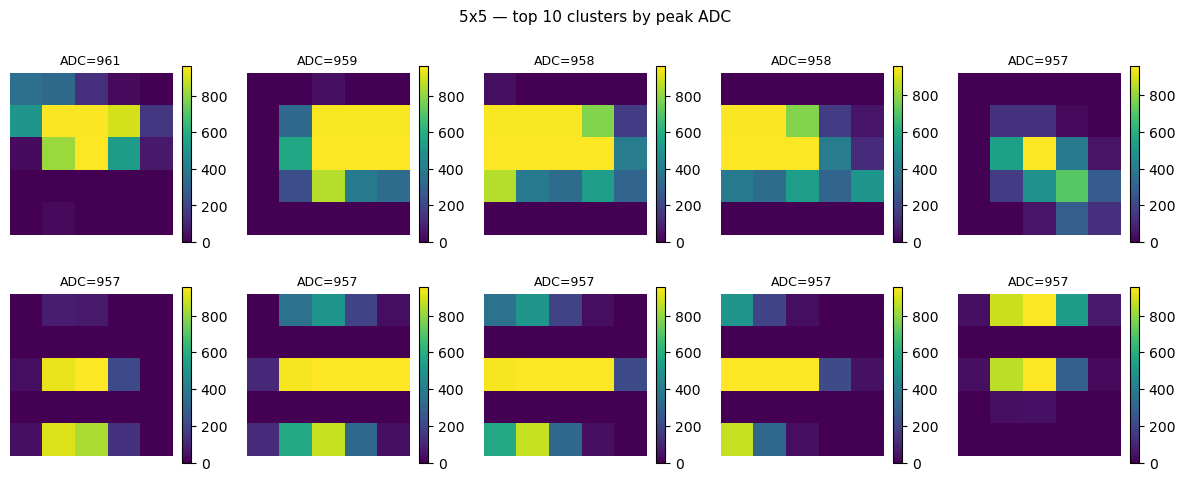

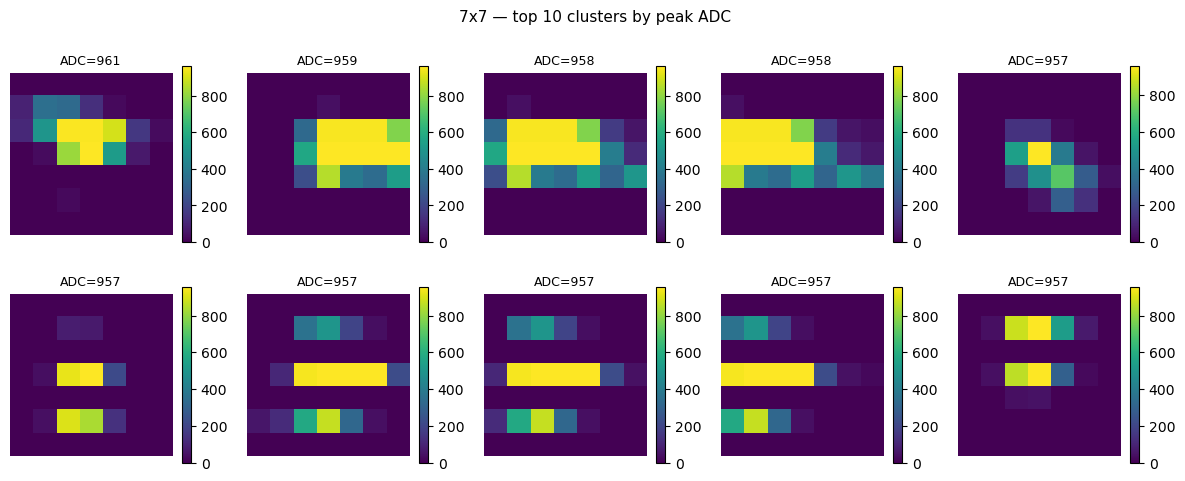

In [19]:
# display cluster patches + 5x5 vs 7x7 comparison
px_cols = {5: [f'p{k:02d}' for k in range(25)], 7: [f'p{k:02d}' for k in range(49)]}

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for col_i, PATCH in enumerate([5, 7]):
    vals = results[PATCH][px_cols[PATCH]].values
    n_nonzero = (vals > 0).sum(axis=1)
    adc_max = vals.max(axis=1)
    adc_mean = vals.mean(axis=1)

    # 直方图1：非零像素数
    axes[0, col_i].hist(n_nonzero, bins=range(0, PATCH * PATCH + 2), color='steelblue', edgecolor='white')
    axes[0, col_i].axvline(np.median(n_nonzero), color='red', linestyle='--', label=f'median={np.median(n_nonzero):.0f}')
    axes[0, col_i].set_title(f'{PATCH}x{PATCH}  pixels with ADC > 0')
    axes[0, col_i].set_xlabel('non-zero pixel count')
    axes[0, col_i].legend()

    # 直方图2：最大ADC
    axes[1, col_i].hist(adc_max, bins=40, color='darkorange', edgecolor='white')
    axes[1, col_i].axvline(np.median(adc_max), color='red', linestyle='--', label=f'median={np.median(adc_max):.0f}')
    axes[1, col_i].set_title(f'{PATCH}x{PATCH}  max ADC per cluster')
    axes[1, col_i].set_xlabel('max ADC')
    axes[1, col_i].legend()

    # 直方图3：平均ADC
    axes[2, col_i].hist(adc_mean, bins=40, color='seagreen', edgecolor='white')
    axes[2, col_i].axvline(np.median(adc_mean), color='red', linestyle='--', label=f'median={np.median(adc_mean):.2f}')
    axes[2, col_i].set_title(f'{PATCH}x{PATCH}  mean ADC per cluster')
    axes[2, col_i].set_xlabel('mean ADC')
    axes[2, col_i].legend()

plt.suptitle(f'Event {EVENT}, Layer {LAYER} — 5x5 vs 7x7', fontsize=12)
plt.tight_layout()
plt.show()

# top 10 cluster patches 目视检查
for PATCH in [5, 7]:
    center = (PATCH * PATCH) // 2
    top10 = results[PATCH].nlargest(10, f'p{center:02d}')
    
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.patch.set_facecolor('white')
    
    for i, (_, r) in enumerate(top10.iterrows()):
        patch_img = r[px_cols[PATCH]].values.reshape(PATCH, PATCH)
        ax = axes[i // 5, i % 5]
        im = ax.imshow(patch_img, cmap='viridis', aspect='equal',
                       interpolation='nearest')
        fig.colorbar(im, ax=ax, shrink=0.8)
        ax.set_title(f'ADC={r[f"p{center:02d}"]:.0f}', fontsize=9)
        ax.axis('off')
    
    plt.suptitle(f'{PATCH}x{PATCH} — top 10 clusters by peak ADC', fontsize=11)
    plt.tight_layout()
    plt.show()

In [20]:
#save to csv
results[5].to_csv("/Users/amandadongsmacbookpro/Desktop/Gunther Research/Research/output/clusters_ev74_l25_5x5.csv", index=False)
print('saved 5x5')

saved 5x5
